/tmp/ipykernel_1236/3551819619.py:94: RuntimeWarning: invalid value encountered in subtract
  t_prime = (4.0 * u_n1 - u_n2) / 3.0


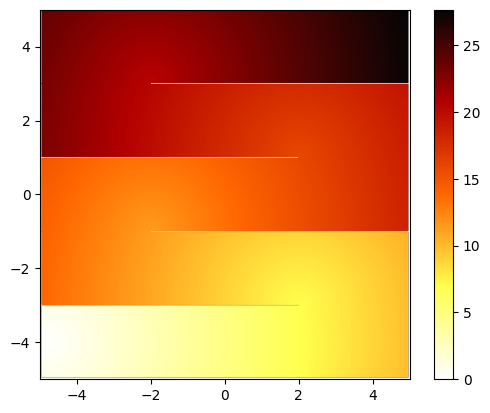

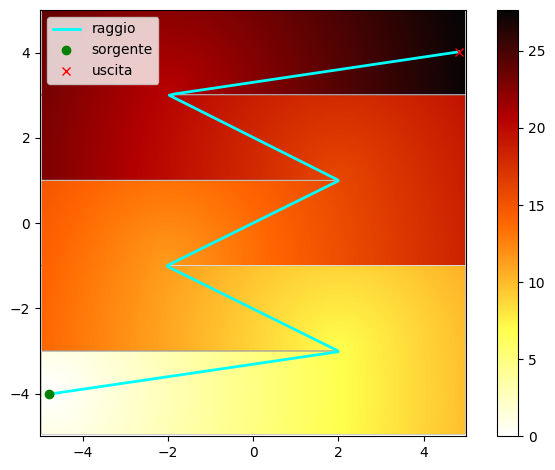

In [ ]:
# ==============================================================================
# ----FIM CON GODUNOV 2 + RAGGI CON INTERP. QUADRATICA SU LABIRINTO 500X500 ----
# ==============================================================================

"""
Il seguente codice utilizza il metodo del FIM classico (v2) con l'aggiornamento
di Godunov del 2° ordine (quello a 4 punti) per generare la soluzione T_final
su cui poi è stato integrato il raggio tramite il metodo di Rounge-Kutta del 4°ordine.
In questo codice il gradiente non viene discretizzato direttamente da T, ma si
esegue prima un interpolazione quadratica stile Lagrange di tutto il campo T
tramite i polinomi di Hermite e poi su questo campo vengono direttamente
calcolate le derivate ∂T/∂x e ∂T/∂y. Nota che in prossimità dei muri il calcolo
è stato fatto degenerare all'ordine lineare per evitare che l'interpolatore
prenda punti che siano su o oltre i muri.
"""

#------------------  LIBRERIE --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import distance_transform_edt
# from google.colab import drive

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------
ny = 500
nx = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)

#punto iniziale (sorgente)
ix0 = 10
iy0 = 50

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0

#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------
F = np.ones(X.shape)
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), F.T, method='linear', bounds_error=False, fill_value=None)

F = 1 * np.ones(X.shape)

# pareti del bordo
F[:, 1]   = np.inf   # bordo sinistro
F[:, 498] = np.inf   # bordo destro
F[1, :]   = np.inf   # borso superiore
F[498, :] = np.inf   # borso inferiore

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[99, :]       = np.inf
F[99, 349:498] = 1
# secondo muro orizzontale (riga 200, con apertura a destra)
F[199, :]      = np.inf
F[199, 1:150]  = 1
# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 349:498] = 1
# quarto muro orizzontale (riga 400, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:150]  = 1

wall_mask = np.isinf(F)

# ==============================================================================
# CALCOLO FIM
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

T_old = np.full(T.shape, np.inf)
continua = True
h = dx

#------------------ GODUNOV 2 --------------------------------------------------

def _dir_contribution(u0, u_n1, u_n2, valid1, valid2, alpha, alpha_prime):

    use = valid1 & (u0 > u_n1)

    second_ok = use & valid2 & (u_n2 < u_n1)
    first_ok  = use & ~second_ok

    t_prime = (4.0 * u_n1 - u_n2) / 3.0
    beta2   = -2.0 * alpha_prime * t_prime
    gamma2  = alpha_prime * (t_prime ** 2)

    beta1  = -(2.0 * u_n1 * alpha)
    gamma1 = (u_n1 ** 2) * alpha

    a_c = np.where(second_ok, alpha_prime, np.where(first_ok, alpha, 0.0))
    b_c = np.where(second_ok, beta2,       np.where(first_ok, beta1, 0.0))
    c_c = np.where(second_ok, gamma2,      np.where(first_ok, gamma1, 0.0))

    return a_c, b_c, c_c


def Godunov_update_2nd(T, F, row, col):

    u0 = T[row, col]

    def neighbor(rr, cc, axis_len_r=nRows, axis_len_c=nCols):
        rr_c = np.clip(rr, 0, axis_len_r - 1)
        cc_c = np.clip(cc, 0, axis_len_c - 1)
        return rr_c, cc_c

    # --- direzione riga meno (i-1, i-2) ---
    r_m1, r_m2 = row - 1, row - 2
    rc1, _ = neighbor(r_m1, col)
    rc2, _ = neighbor(r_m2, col)
    valid_m1 = (r_m1 >= 0) & ~wall_mask[rc1, col]
    valid_m2 = valid_m1 & (r_m2 >= 0) & ~wall_mask[rc2, col]
    u_rm1, u_rm2 = T[rc1, col], T[rc2, col]

    # --- direzione riga più (i+1, i+2) ---
    r_p1, r_p2 = row + 1, row + 2
    rc1, _ = neighbor(r_p1, col)
    rc2, _ = neighbor(r_p2, col)
    valid_p1 = (r_p1 < nRows) & ~wall_mask[rc1, col]
    valid_p2 = valid_p1 & (r_p2 < nRows) & ~wall_mask[rc2, col]
    u_rp1, u_rp2 = T[rc1, col], T[rc2, col]

    # --- direzione colonna meno (j-1, j-2) ---
    c_m1, c_m2 = col - 1, col - 2
    _, cc1 = neighbor(row, c_m1)
    _, cc2 = neighbor(row, c_m2)
    valid_cm1 = (c_m1 >= 0) & ~wall_mask[row, cc1]
    valid_cm2 = valid_cm1 & (c_m2 >= 0) & ~wall_mask[row, cc2]
    u_cm1, u_cm2 = T[row, cc1], T[row, cc2]

    # --- direzione colonna più (j+1, j+2) ---
    c_p1, c_p2 = col + 1, col + 2
    _, cc1 = neighbor(row, c_p1)
    _, cc2 = neighbor(row, c_p2)
    valid_cp1 = (c_p1 < nCols) & ~wall_mask[row, cc1]
    valid_cp2 = valid_cp1 & (c_p2 < nCols) & ~wall_mask[row, cc2]
    u_cp1, u_cp2 = T[row, cc1], T[row, cc2]

    alpha       = 1.0 / (h ** 2)
    alpha_prime = 9.0 / (4.0 * h ** 2)

    a = np.zeros_like(u0)
    b = np.zeros_like(u0)
    c = -(F[row, col] ** 2) * np.ones_like(u0)

    for u_n1, u_n2, v1, v2 in [
        (u_rm1, u_rm2, valid_m1, valid_m2),
        (u_rp1, u_rp2, valid_p1, valid_p2),
        (u_cm1, u_cm2, valid_cm1, valid_cm2),
        (u_cp1, u_cp2, valid_cp1, valid_cp2),
    ]:
        a_c, b_c, c_c = _dir_contribution(u0, u_n1, u_n2, v1, v2, alpha, alpha_prime)
        a += a_c
        b += b_c
        c += c_c

    disc = b ** 2 - 4.0 * a * c

    safe_a = np.where(a == 0, 1.0, a)          # evita divisione per zero
    u_quad = (-b + np.sqrt(np.maximum(disc, 0.0))) / (2.0 * safe_a)
    u_lin  = -b / (2.0 * safe_a)               # ramo "not isreal" del MATLAB

    u_new = np.where(disc >= 0, u_quad, u_lin)
    u_new = np.where(a == 0, u0, u_new)        # nessun vicino valido: resta invariato

    return np.minimum(u0, u_new)

#------------------  AGGIORNAMENTO FIM -----------------------------------------

def FIM(T, F, active):

    while np.any(active):

        row, col = np.where(active)
        p = T[row, col]
        q = Godunov_update_2nd(T, F, row, col)
        T[row, col] = q

        converged_cond = np.abs(p - q) < 1e-6
        conv_row, conv_col = row[converged_cond], col[converged_cond]

        active[conv_row, conv_col] = False

        for r, c in [(0, -1), (0, 1), (-1, 0), (1, 0)]:
            nb_row = conv_row + r
            nb_col = conv_col + c

            valid = (nb_row >= 0) & (nb_row < nRows) & (nb_col >= 0) & (nb_col < nCols)
            nb_row, nb_col = nb_row[valid], nb_col[valid]

            not_active = ~active[nb_row, nb_col]

            wall = np.isinf(F[nb_row, nb_col])

            nb_row = nb_row[~wall]
            nb_col = nb_col[~wall]

            if nb_row.size == 0:
                continue

            p2 = T[nb_row, nb_col]
            q2 = Godunov_update_2nd(T, F, nb_row, nb_col)

            improve = q2 < p2
            nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

            T[nb_row, nb_col] = q2
            active[nb_row, nb_col] = True

    return T


T_final = FIM(T, F, active)

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)


# ==============================================================================
# CALCOLO RAGGI CON INTERPOLAZIONE QUADRATICA ADATTIVA
# ==============================================================================

#------------------  UTILITY FUNCTION ------------------------------------------

#ulteriore guard che serve a clippare gli indici che escono dai bordi
def clamp_index(j, n):
    return min(max(j, 1), n - 3)

#serve a restituire true se il punto (row,col) è un muro o è fuori dai bordi ed
#è utilizzata dalle funzioni hermitiane per controllare dove hanno il muro
def is_wall_rc(row, col, wall_mask):
    nrows, ncols = wall_mask.shape
    if row < 0 or row >= nrows or col < 0 or col >= ncols:
        return True
    return bool(wall_mask[row, col])

def is_wall_at(pt, F, x, y):
    col = np.clip(np.searchsorted(x, pt[0])- 1 , 0, F.shape[1] - 1)
    row = np.clip(np.searchsorted(y, pt[1]) - 1 , 0, F.shape[0] - 1)
    return np.isinf(F[row, col])


#------------------  INTERPOLAZIONE QUADRATICA (ordine 2) -----------------------

def quad_1d_or_fallback(f_m2, f_m1, f_0, f_1, f_2, s, h,
                         wall_m2=False, wall_m1=False,
                         wall_1=False, wall_2=False,
                         wall_0=False):
    """
    Interpolazione quadratica di Lagrange, stencil nominale {f_m1, f_0, f_1}
    con s = (x - x0)/h. Include il controllo sul nodo base f_0 e sul nodo
    f_1, oltre al fallback laterale sui vicini più esterni.
    """
    if wall_0 and wall_1:
        return 0.0, 0.0  # entrambi i nodi centrali sono muro: caso patologico

    if wall_0 and not wall_1:
        # f_0 è muro: non posso centrare qui, ripiego forward da f_1
        deriv = (f_2 - f_1) / h if not wall_2 else 0.0
        return f_1, deriv

    if wall_1 and not wall_0:
        # f_1 è muro: ripiego backward da f_0
        deriv = (f_0 - f_m1) / h if not wall_m1 else 0.0
        return f_0, deriv

    # --- da qui in poi f_0 e f_1 sono entrambi liberi ---

    if wall_m1 and not wall_1:
        if wall_2:
            deriv = (f_1 - f_0) / h
            val = f_0 + s * h * deriv
            return val, deriv
        d1 = f_1 - f_0
        d2 = f_2 - 2*f_1 + f_0
        val = f_0 + s*d1 + s*(s - 1)/2*d2
        dval_ds = d1 + (2*s - 1)/2*d2
        return val, dval_ds / h

    if wall_m2 and not wall_m1:
        deriv = (f_0 - f_m1) / h
        val = f_m1 + (s + 1) * h * deriv
        return val, deriv

    # --- caso libero: quadratica centrata standard ---
    val = f_0 + (f_1 - f_m1)/2*s + (f_1 - 2*f_0 + f_m1)/2*s**2
    dval_ds = (f_1 - f_m1)/2 + (f_1 - 2*f_0 + f_m1)*s
    return val, dval_ds / h


def clamp_index_quad(j, n):
    return min(max(j, 2), n - 3)


def quad_local_grad(pt, T_field, wall_mask, x, y, dx, dy):
    px, py = pt
    nrows, ncols = T_field.shape

    jx = int(np.floor((px - x[0]) / dx))
    jy = int(np.floor((py - y[0]) / dy))

    jx = clamp_index_quad(jx, ncols)
    jy = clamp_index_quad(jy, nrows)

    sx = (px - x[jx]) / dx
    sy = (py - y[jy]) / dy

    g_val = np.empty(5)
    g_dx  = np.empty(5)
    for k, ry in enumerate((-2, -1, 0, 1, 2)):
        row = jy + ry
        f_m2 = T_field[row, jx - 2]
        f_m1 = T_field[row, jx - 1]
        f_0  = T_field[row, jx]
        f_1  = T_field[row, jx + 1]
        f_2  = T_field[row, jx + 2]

        wall_m2 = is_wall_rc(row, jx - 2, wall_mask)
        wall_m1 = is_wall_rc(row, jx - 1, wall_mask)
        wall_0  = is_wall_rc(row, jx, wall_mask)
        wall_1  = is_wall_rc(row, jx + 1, wall_mask)
        wall_2  = is_wall_rc(row, jx + 2, wall_mask)

        g_val[k], g_dx[k] = quad_1d_or_fallback(
            f_m2, f_m1, f_0, f_1, f_2, sx, dx,
            wall_m2=wall_m2, wall_m1=wall_m1,
            wall_1=wall_1, wall_2=wall_2, wall_0=wall_0)

    wall_m2y = is_wall_rc(jy - 2, jx, wall_mask) or is_wall_rc(jy - 2, jx + 1, wall_mask)
    wall_m1y = is_wall_rc(jy - 1, jx, wall_mask) or is_wall_rc(jy - 1, jx + 1, wall_mask)
    wall_0y  = is_wall_rc(jy, jx, wall_mask)     or is_wall_rc(jy, jx + 1, wall_mask)
    wall_1y  = is_wall_rc(jy + 1, jx, wall_mask) or is_wall_rc(jy + 1, jx + 1, wall_mask)
    wall_2y  = is_wall_rc(jy + 2, jx, wall_mask) or is_wall_rc(jy + 2, jx + 1, wall_mask)

    _, dT_dy = quad_1d_or_fallback(
        g_val[0], g_val[1], g_val[2], g_val[3], g_val[4], sy, dy,
        wall_m2=wall_m2y, wall_m1=wall_m1y,
        wall_1=wall_1y, wall_2=wall_2y, wall_0=wall_0y)

    dT_dx, _ = quad_1d_or_fallback(
        g_dx[0], g_dx[1], g_dx[2], g_dx[3], g_dx[4], sy, dy,
        wall_m2=wall_m2y, wall_m1=wall_m1y,
        wall_1=wall_1y, wall_2=wall_2y, wall_0=wall_0y)

    return dT_dx, dT_dy

#------------------  NORMALIZZAZIONE DEL GRADIENTE -----------------------------

def grad_at_local(pt, T_field, wall_mask, x, y, dx, dy):
    gx, gy = quad_local_grad(pt, T_field, wall_mask, x, y, dx, dy)
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    norm = np.sqrt(gx**2 + gy**2)
    if norm < 1e-12:
        return np.array([0.0, 0.0])
    scale = 1.0 / norm   # forza |grad T| = 1 (coerente con F=1 fuori dai muri)
    return np.array([gx * scale, gy * scale])

#------------------  RUNGE-KUTTA 4°ORDINE --------------------------------------

def trace_ray_rk4(start_pt, T_field, wall_mask, source_pt, ds, max_steps, F, x, y, dx, dy):
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        k1 = -grad_at_local(pt, T_field, wall_mask, x, y, dx, dy)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at_local(pt + 0.5*ds*k1, T_field, wall_mask, x, y, dx, dy)
        k3 = -grad_at_local(pt + 0.5*ds*k2, T_field, wall_mask, x, y, dx, dy)
        k4 = -grad_at_local(pt + ds*k3, T_field, wall_mask, x, y, dx, dy)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0

        step_ds = ds
        pt_new = pt + step_ds * dpt
        n_tries = 0
        while is_wall_at(pt_new, F, x, y) and n_tries < 8:
            step_ds *= 0.5
            pt_new = pt + step_ds * dpt
            n_tries += 1

        ray.append(pt_new.copy())

        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)

#------------------  CHIAMATA FINALE -------------------------------------------

source_pt = (x[ix0], y[iy0])  #punto sorgente
exit_pt = (x[490], y[450])  #punto finale

ds = dx/2   #passo di discretizzazione di rk4
max_steps = 10000

ray = trace_ray_rk4(exit_pt, T_final, wall_mask, source_pt, ds, max_steps, F, x, y, dx, dy)

#------------------  PLOT RAGGIO -----------------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='raggio')
ax.plot(*source_pt, 'go', label='sorgente')
ax.plot(*exit_pt, 'rx', label='uscita')
ax.legend()
plt.tight_layout()
plt.show()